# Exploring a single-band raster with `Dataset`

This tutorial opens a one-band MSWEP precipitation raster covering South America and uses it to tour the
read-only properties of a pyramids `Dataset`. You will learn how to inspect a raster's dimensions, band
metadata, geospatial referencing, driver details, and pixel values, then copy the dataset, add a band, read
windowed blocks, compute statistics, and attach an attribute table. Every attribute shown here is available
on any `Dataset`, whatever its file format.

## Load the raster

We import the `Dataset` class and point at the GeoTIFF — one day of MSWEP rainfall over South America.
The path is relative to this notebook.

In [1]:
# NBVAL_IGNORE_OUTPUT
from pyramids.dataset import Dataset

%matplotlib inline

path = r"../../../examples/data/geotiff/south-america-mswep_1979010100.tif"

2026-07-01 17:23:33 | INFO | pyramids.base.config | Logging is configured.


`read_file` opens the raster through GDAL; printing the returned `Dataset` gives a one-glance summary of its grid,
CRS, and bands.

In [2]:
dataset = Dataset.read_file(path)
print(dataset)


            Top Left Corner: (-110.0, 18.1)
            Cell size: 0.1
            Dimension: 780 * 850
            EPSG: 4326
            Number of Bands: 1
            Band names: ['Band_1']
            Band colors: {0: 'gray_index'}
            Band units: ['']
            Scale: [1.0]
            Offset: [0]
            Mask: -9999.0
            Data type: float32
            File: ../../../examples/data/geotiff/south-america-mswep_1979010100.tif
        


Draw the band as a map so we can see the rainfall field we are about to inspect.

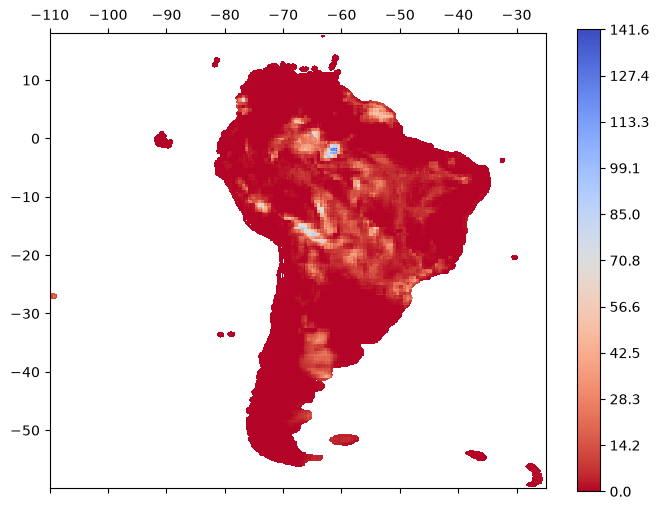

In [3]:
dataset.plot()

The map shows daily rainfall across South America: wetter cells stand out over the tropical north and the Andes,
while much of the continent is dry on this particular day.

## Raster dimensions

The first thing to know about a raster is its grid geometry: the size of each pixel and how many rows and
columns it has. These properties describe the shape of the array without reading any pixel values.

In [4]:
print(dataset.cell_size)

0.1


`rows` and `columns` report the grid height and width in pixels.

In [5]:
print(f"Rows , Columns = {dataset.rows}, {dataset.columns}")

Rows , Columns = 780, 850


`shape` returns the array shape as `(bands, rows, columns)` — the same layout NumPy uses.

In [6]:
print(dataset.shape)

(1, 780, 850)


`band_count` is the number of bands; this rainfall raster has just one.

In [7]:
print(dataset.band_count)

1


## Band information

Each band carries its own metadata: a name, a data type, physical units, and optional scale/offset factors
used to decode stored numbers into real-world values.

In [8]:
print(dataset.band_names)

['Band_1']


`dtype` is the pixel data type (here a 32-bit float).

In [9]:
print(dataset.dtype)

['float32']


`band_units` lists the physical unit of each band, when the file records one.

In [10]:
print(dataset.band_units)

['']


`scale` is the multiplier applied when decoding stored values.

In [11]:
print(dataset.scale)

[1.0]


`offset` is the constant added after scaling; together `scale` and `offset` map stored numbers to physical values.

In [12]:
print(dataset.offset)

[0]


## Geospatial information

These properties tie the pixel grid to real-world locations: the affine geotransform, the bounding box, the
coordinate reference system, and the per-axis coordinate arrays.

In [13]:
print(dataset.geotransform)
print(dataset.top_left_corner)

(-110.0, 0.1, 0.0, 18.1, 0.0, -0.1)
(-110.0, 18.1)


`bounds` returns the raster's extent as a `GeoDataFrame` — a one-row polygon of its footprint.

In [14]:
print(dataset.bounds)

                                            geometry
0  POLYGON ((-110 18.1, -110 -59.9, -25 -59.9, -2...


`bbox` returns the same extent as a plain `[xmin, ymin, xmax, ymax]` list.

In [15]:
print(dataset.bbox)

[-110.0, -59.9, -25.0, 18.1]


`epsg` is the numeric CRS code; `crs` is its full WKT description.

In [16]:
print(dataset.epsg)
print(dataset.crs)

4326
GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


`no_data_value` is the sentinel marking cells with no measurement — masked out in plots and statistics.

In [17]:
print(dataset.no_data_value)

(-9999.0,)


`lon` is the array of longitude coordinates for the grid columns.

In [18]:
print(dataset.lon)

[-109.95 -109.85 -109.75 -109.65 -109.55 -109.45 -109.35 -109.25 -109.15
 -109.05 -108.95 -108.85 -108.75 -108.65 -108.55 -108.45 -108.35 -108.25
 -108.15 -108.05 -107.95 -107.85 -107.75 -107.65 -107.55 -107.45 -107.35
 -107.25 -107.15 -107.05 -106.95 -106.85 -106.75 -106.65 -106.55 -106.45
 -106.35 -106.25 -106.15 -106.05 -105.95 -105.85 -105.75 -105.65 -105.55
 -105.45 -105.35 -105.25 -105.15 -105.05 -104.95 -104.85 -104.75 -104.65
 -104.55 -104.45 -104.35 -104.25 -104.15 -104.05 -103.95 -103.85 -103.75
 -103.65 -103.55 -103.45 -103.35 -103.25 -103.15 -103.05 -102.95 -102.85
 -102.75 -102.65 -102.55 -102.45 -102.35 -102.25 -102.15 -102.05 -101.95
 -101.85 -101.75 -101.65 -101.55 -101.45 -101.35 -101.25 -101.15 -101.05
 -100.95 -100.85 -100.75 -100.65 -100.55 -100.45 -100.35 -100.25 -100.15
 -100.05  -99.95  -99.85  -99.75  -99.65  -99.55  -99.45  -99.35  -99.25
  -99.15  -99.05  -98.95  -98.85  -98.75  -98.65  -98.55  -98.45  -98.35
  -98.25  -98.15  -98.05  -97.95  -97.85  -97.75  -

`lat` is the array of latitude coordinates for the grid rows.

In [19]:
print(dataset.lat)

[ 1.805e+01  1.795e+01  1.785e+01  1.775e+01  1.765e+01  1.755e+01
  1.745e+01  1.735e+01  1.725e+01  1.715e+01  1.705e+01  1.695e+01
  1.685e+01  1.675e+01  1.665e+01  1.655e+01  1.645e+01  1.635e+01
  1.625e+01  1.615e+01  1.605e+01  1.595e+01  1.585e+01  1.575e+01
  1.565e+01  1.555e+01  1.545e+01  1.535e+01  1.525e+01  1.515e+01
  1.505e+01  1.495e+01  1.485e+01  1.475e+01  1.465e+01  1.455e+01
  1.445e+01  1.435e+01  1.425e+01  1.415e+01  1.405e+01  1.395e+01
  1.385e+01  1.375e+01  1.365e+01  1.355e+01  1.345e+01  1.335e+01
  1.325e+01  1.315e+01  1.305e+01  1.295e+01  1.285e+01  1.275e+01
  1.265e+01  1.255e+01  1.245e+01  1.235e+01  1.225e+01  1.215e+01
  1.205e+01  1.195e+01  1.185e+01  1.175e+01  1.165e+01  1.155e+01
  1.145e+01  1.135e+01  1.125e+01  1.115e+01  1.105e+01  1.095e+01
  1.085e+01  1.075e+01  1.065e+01  1.055e+01  1.045e+01  1.035e+01
  1.025e+01  1.015e+01  1.005e+01  9.950e+00  9.850e+00  9.750e+00
  9.650e+00  9.550e+00  9.450e+00  9.350e+00  9.250e+00  9.150

`x` gives the column coordinates in the dataset's native CRS units (identical to `lon` for a geographic raster).

In [20]:
print(dataset.x)

[-109.95 -109.85 -109.75 -109.65 -109.55 -109.45 -109.35 -109.25 -109.15
 -109.05 -108.95 -108.85 -108.75 -108.65 -108.55 -108.45 -108.35 -108.25
 -108.15 -108.05 -107.95 -107.85 -107.75 -107.65 -107.55 -107.45 -107.35
 -107.25 -107.15 -107.05 -106.95 -106.85 -106.75 -106.65 -106.55 -106.45
 -106.35 -106.25 -106.15 -106.05 -105.95 -105.85 -105.75 -105.65 -105.55
 -105.45 -105.35 -105.25 -105.15 -105.05 -104.95 -104.85 -104.75 -104.65
 -104.55 -104.45 -104.35 -104.25 -104.15 -104.05 -103.95 -103.85 -103.75
 -103.65 -103.55 -103.45 -103.35 -103.25 -103.15 -103.05 -102.95 -102.85
 -102.75 -102.65 -102.55 -102.45 -102.35 -102.25 -102.15 -102.05 -101.95
 -101.85 -101.75 -101.65 -101.55 -101.45 -101.35 -101.25 -101.15 -101.05
 -100.95 -100.85 -100.75 -100.65 -100.55 -100.45 -100.35 -100.25 -100.15
 -100.05  -99.95  -99.85  -99.75  -99.65  -99.55  -99.45  -99.35  -99.25
  -99.15  -99.05  -98.95  -98.85  -98.75  -98.65  -98.55  -98.45  -98.35
  -98.25  -98.15  -98.05  -97.95  -97.85  -97.75  -

`y` gives the row coordinates in native CRS units (identical to `lat` here).

In [21]:
print(dataset.y)

[ 1.805e+01  1.795e+01  1.785e+01  1.775e+01  1.765e+01  1.755e+01
  1.745e+01  1.735e+01  1.725e+01  1.715e+01  1.705e+01  1.695e+01
  1.685e+01  1.675e+01  1.665e+01  1.655e+01  1.645e+01  1.635e+01
  1.625e+01  1.615e+01  1.605e+01  1.595e+01  1.585e+01  1.575e+01
  1.565e+01  1.555e+01  1.545e+01  1.535e+01  1.525e+01  1.515e+01
  1.505e+01  1.495e+01  1.485e+01  1.475e+01  1.465e+01  1.455e+01
  1.445e+01  1.435e+01  1.425e+01  1.415e+01  1.405e+01  1.395e+01
  1.385e+01  1.375e+01  1.365e+01  1.355e+01  1.345e+01  1.335e+01
  1.325e+01  1.315e+01  1.305e+01  1.295e+01  1.285e+01  1.275e+01
  1.265e+01  1.255e+01  1.245e+01  1.235e+01  1.225e+01  1.215e+01
  1.205e+01  1.195e+01  1.185e+01  1.175e+01  1.165e+01  1.155e+01
  1.145e+01  1.135e+01  1.125e+01  1.115e+01  1.105e+01  1.095e+01
  1.085e+01  1.075e+01  1.065e+01  1.055e+01  1.045e+01  1.035e+01
  1.025e+01  1.015e+01  1.005e+01  9.950e+00  9.850e+00  9.750e+00
  9.650e+00  9.550e+00  9.450e+00  9.350e+00  9.250e+00  9.150

## Driver and file metadata

Beyond the pixels, a `Dataset` knows how it is stored: the GDAL driver, the internal tiling/block size, the
source file name, and any key/value metadata tags.

In [22]:
print(dataset.meta_data)

{'AREA_OR_POINT': 'Area'}


`block_size` is the internal tile size GDAL reads in one chunk — important for efficient windowed reads.

In [23]:
print(dataset.block_size)

[[850, 2]]


`file_name` is the path the dataset was opened from.

In [24]:
print(dataset.file_name)

../../../examples/data/geotiff/south-america-mswep_1979010100.tif


`driver_type` names the GDAL driver backing the dataset (GeoTIFF here).

In [25]:
print(dataset.driver_type)

geotiff


## Create a copy of the dataset

`copy` returns an independent in-memory clone, so you can modify it freely without touching the original
file on disk.

In [26]:
dataset_copy = dataset.copy()
print(dataset_copy)


            Top Left Corner: (-110.0, 18.1)
            Cell size: 0.1
            Dimension: 780 * 850
            EPSG: 4326
            Number of Bands: 1
            Band names: ['Band_1']
            Band colors: {0: 'gray_index'}
            Band units: ['']
            Scale: [1.0]
            Offset: [0]
            Mask: -9999.0
            Data type: float32
            File: 
        


## Add a new band

`add_band` appends an extra band from a NumPy array. Here we stack a random array shaped to the grid as a
second band and give it a unit.

In [27]:
import numpy as np

new_band = np.random.rand(dataset.rows, dataset.columns)
new_dataset = dataset.add_band(new_band, unit="mm")
print(new_dataset)


            Top Left Corner: (-110.0, 18.1)
            Cell size: 0.1
            Dimension: 780 * 850
            EPSG: 4326
            Number of Bands: 2
            Band names: ['Band_1', 'Band_2']
            Band colors: {0: 'gray_index', 1: 'undefined'}
            Band units: ['', 'mm']
            Scale: [1.0, 1.0]
            Offset: [0, 0]
            Mask: -9999.0
            Data type: float32
            File: 
        


## Read band values

So far we only inspected metadata. `read_array` is what actually pulls pixel values into a NumPy array —
either the whole raster at once or a windowed block.

In [28]:
arr = dataset.read_array()
print(arr.shape)

(780, 850)


Display the array itself to see the raw rainfall values, including the no-data cells.

In [29]:
arr

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      shape=(780, 850), dtype=float32)

Most cells hold small floating-point rainfall values; the large negative entries are the no-data sentinel seen above.

`read_array` with a `window=(x, y, width, height)` reads only a sub-block — here the top-left 100x100 pixels —
instead of loading the whole raster into memory.

In [30]:
block = dataset.read_array(band=0, window=(0, 0, 100, 100))
print(block.shape)
print(block)

(100, 100)
[[-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 ...
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]]


`get_block_arrangement` lists how the raster would be tiled into blocks of the given size, handy for chunked,
memory-safe processing of large rasters.

In [31]:
dataset.get_block_arrangement(x_block_size=100, y_block_size=100)

,x_offset,y_offset,window_xsize,window_ysize
0,0,0,100,100
1,100,0,100,100
2,200,0,100,100
3,300,0,100,100
4,400,0,100,100
...,...,...,...,...
67,400,700,100,80
68,500,700,100,80
69,600,700,100,80
70,700,700,100,80


## Band statistics

`stats` computes summary statistics (min, max, mean, standard deviation) for a band, skipping no-data cells.

In [32]:
stats = dataset.stats(band=0)
stats

,min,max,mean,std
Band_1,-9998.992188,65.326111,-1949.050171,3413.121826


The statistics summarise the whole band in one row — a quick way to read the value range and spot outliers before analysis.

## Attribute table

A raster band can carry a raster attribute table (RAT) — a small lookup table that gives meaning to pixel
values, much like a map legend. Below we read the current table, then set our own.

### Read the band attribute table

In [33]:
df = dataset.get_attribute_table(band=0)
print(df)

  Precipitation Range (mm)   Category              Description
0                     0-50        Low   Very low precipitation
1                   51-100   Moderate   Moderate precipitation
2                  101-200       High       High precipitation
3                  201-500  Very High  Very high precipitation
4                     >500    Extreme    Extreme precipitation


The raster ships without a predefined attribute table, so the returned frame is empty — we populate it next.

### Set the band attribute table

`set_attribute_table` attaches a pandas DataFrame to the band, labelling ranges of pixel values with a
category and description — turning bare numbers into an interpretable legend.

In [34]:
import pandas as pd

attribute_table = {
    'Precipitation Range (mm)': ['0-50', '51-100', '101-200', '201-500', '>500'],
    'Category': ['Low', 'Moderate', 'High', 'Very High', 'Extreme'],
    'Description': [
        'Very low precipitation',
        'Moderate precipitation',
        'High precipitation',
        'Very high precipitation',
        'Extreme precipitation',
    ],
}
df = pd.DataFrame(attribute_table)
dataset.set_attribute_table(df, band=0)